<a href="https://colab.research.google.com/github/ankush07das/Digital-Image-Watermarking-using-discrete-wavelet-transform/blob/main/FYP_7_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Embed the watermark

In [1]:
!pip install pillow

In [2]:
!pip install PyWavelets

In [3]:
import pywt
import numpy as np
from PIL import Image,ImageEnhance
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

In [4]:
original_image_path = '/content/original_image.jpg'  # Update with correct path
watermark_image_path = '/content/watermark_image.jpg'  # Update with correct path
watermarked_image_path = '/content/watermarked_image.png'
#image_path = r'/content/lena.jpeg'
#watermark_content_path='/content/watermark_content.png'

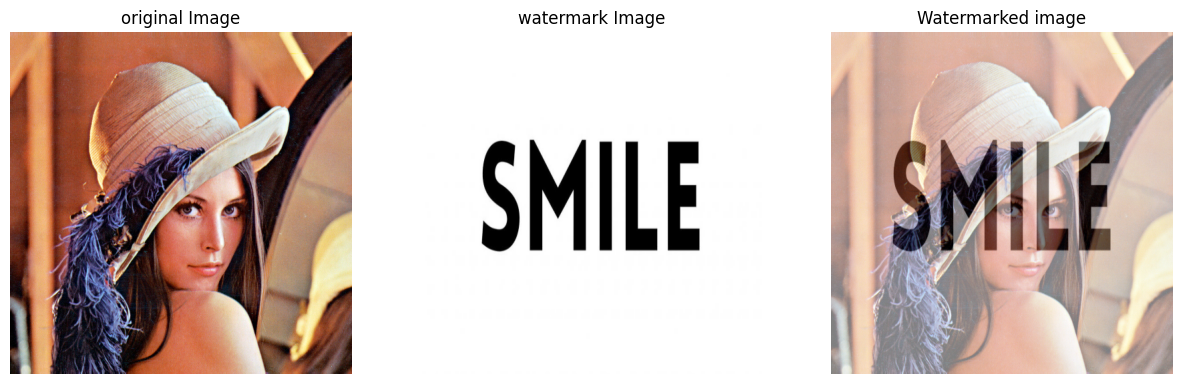

In [13]:
original_image = cv2.imread(original_image_path, cv2.IMREAD_UNCHANGED) # Load original image
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_UNCHANGED)  # Load watermark

# Resize watermark to match the original image size
watermark_image = cv2.resize(watermark_image, (original_image.shape[1], original_image.shape[0]))

# Convert to float32 for blending
original = original_image.astype(np.float32)
watermark = watermark_image.astype(np.float32)

# Define opacity level (0 = invisible, 1 = fully visible)
alpha = 0.5  # Adjust as needed

# Apply alpha blending formula
watermarked_image = ((1 - alpha) * original + alpha * watermark).astype(np.uint8)

# Save and display the watermarked image
cv2.imwrite("/content/watermarked_image.png", watermarked_image)

# Convert to RGB for Matplotlib (since OpenCV loads in BGR format)
watermarked_rgb = cv2.cvtColor(watermarked_image, cv2.COLOR_BGR2RGB)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
# Plot all images in a single figure
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Display original image
ax[0].imshow(original_image)
ax[0].set_title("original Image")
ax[0].axis("off")

# Display watermark image
ax[1].imshow(watermark_image)
ax[1].set_title("watermark Image")
ax[1].axis("off")

# Display extracted watermark
ax[2].imshow(watermarked_rgb)
ax[2].set_title("Watermarked image")
ax[2].axis("off")

# Show the final combined output
plt.show()

Extract the watermark

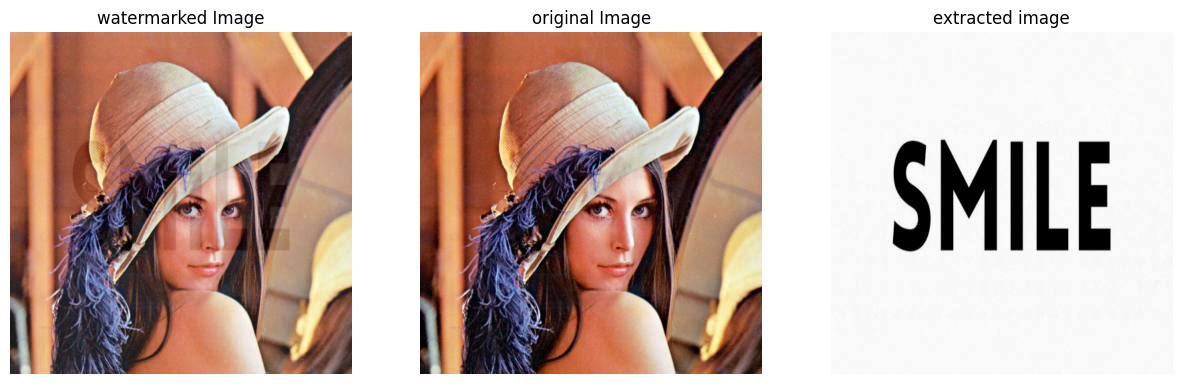

In [6]:
original= cv2.imread(original_image_path, cv2.IMREAD_UNCHANGED).astype(np.float32)
watermarked = cv2.imread(watermarked_image_path, cv2.IMREAD_UNCHANGED).astype(np.float32)

# Define the same opacity level used in watermarking
alpha = 0.1  # Adjust if different opacity was used

# Extract the watermark using the inverse formula
extracted_watermark = (watermarked - (1 - alpha) * original) / (alpha + 1e-6)

# Clip values to ensure they stay in range 0-255
extracted_watermark = np.clip(extracted_watermark, 0, 255).astype(np.uint8)

# Convert to RGB for Matplotlib (since OpenCV loads in BGR format)
extracted_rgb = cv2.cvtColor(extracted_watermark, cv2.COLOR_BGR2RGB)

# Plot all images in a single figure
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# Display original image
ax[0].imshow(watermarked_rgb)
ax[0].set_title("watermarked Image")
ax[0].axis("off")

# Display watermark image
ax[1].imshow(original_image)
ax[1].set_title("original Image")
ax[1].axis("off")

# Display extracted watermark
ax[2].imshow(extracted_rgb)
ax[2].set_title("extracted image")
ax[2].axis("off")

# Show the final combined output
plt.show()

Converting an image to RGBA ana apply DWT

Saving original_image.jpg to original_image (1).jpg


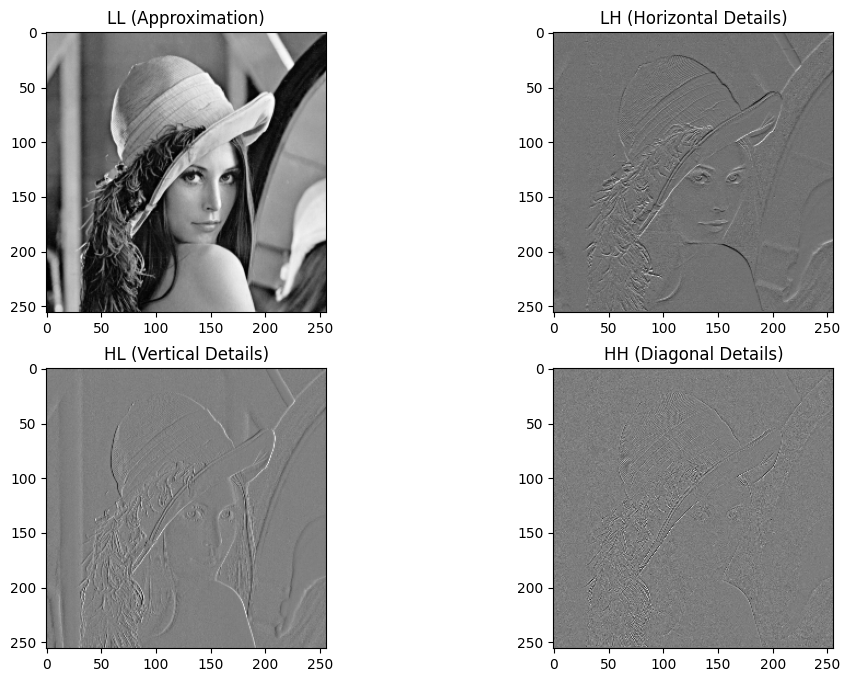

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pywt
from google.colab import files

def process_image_dwt(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    # Convert to RGBA (if it's not already)
    if img.shape[-1] == 3: # If it's BGR, convert to RGBA
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGBA)
    elif img.shape[-1] == 1: #if grayscale convert to RGBA
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGBA)

    # Convert to grayscale for DWT
    gray = cv2.cvtColor(img, cv2.COLOR_RGBA2GRAY)

    # Perform DWT
    coeffs = pywt.dwt2(gray, 'haar')
    LL, (LH, HL, HH) = coeffs

    # Display the results
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(LL, cmap='gray')
    plt.title('LL (Approximation)')

    plt.subplot(2, 2, 2)
    plt.imshow(LH, cmap='gray')
    plt.title('LH (Horizontal Details)')

    plt.subplot(2, 2, 3)
    plt.imshow(HL, cmap='gray')
    plt.title('HL (Vertical Details)')

    plt.subplot(2, 2, 4)
    plt.imshow(HH, cmap='gray')
    plt.title('HH (Diagonal Details)')

    plt.show()

uploaded = files.upload()

if uploaded:
    for filename in uploaded.keys():
        process_image_dwt(filename)
else:
    print("No file uploaded.")

Embed and extract the watermark in each subband image

Upload original image and watermark image...


Saving original_image.jpg to original_image (2).jpg


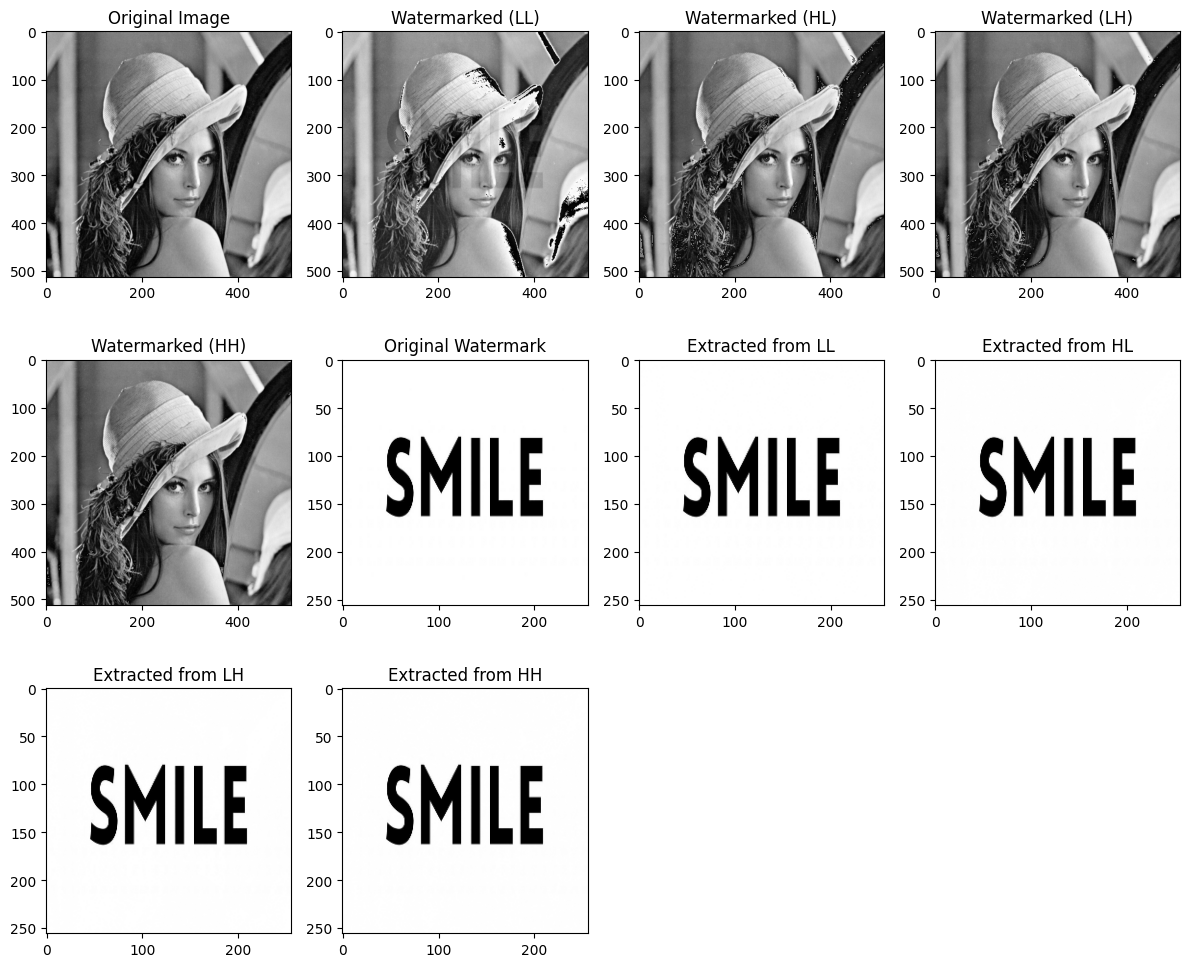

In [8]:
# Install dependencies
!pip install pywavelets opencv-python-headless

import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
from google.colab import files

#  Upload original image and watermark
print("Upload original image and watermark image...")
uploaded = files.upload()

#  Load grayscale images
def load_grayscale(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Failed to load image: {path}")
    return img

original = load_grayscale('/content/original_image.jpg')
watermark = load_grayscale('/content/watermark_image.jpg')

#  Embedding strength
alpha = 0.1

# Resize and normalize watermark
def preprocess_watermark(wm, shape):
    wm_resized = cv2.resize(wm, (shape[1], shape[0]))
    return wm_resized / 255.0  # Normalize to [0,1]

#  Embed watermark in each subband
def embed_watermark(orig_img, wm, alpha):
    # DWT on original image
    LL, (LH, HL, HH) = pywt.dwt2(orig_img, 'haar')

    # Resize watermark
    wm_norm = preprocess_watermark(wm, LL.shape)

    # Embed watermark in each subband
    LL_w = LL + alpha * wm_norm * np.max(LL)
    HL_w = HL + alpha * wm_norm * np.max(HL)
    LH_w = LH + alpha * wm_norm * np.max(LH)
    HH_w = HH + alpha * wm_norm * np.max(HH)

    # Inverse DWT to reconstruct images
    img_LL = pywt.idwt2((LL_w, (LH, HL, HH)), 'haar')
    img_HL = pywt.idwt2((LL, (LH, HL_w, HH)), 'haar')
    img_LH = pywt.idwt2((LL, (LH_w, HL, HH)), 'haar')
    img_HH = pywt.idwt2((LL, (LH, HL, HH_w)), 'haar')

    return img_LL, img_HL, img_LH, img_HH, wm_norm

#  Extract watermark from subband
def extract_watermark(orig_img, wm_img, subband='LL', alpha=0.1):
    orig_LL, (orig_LH, orig_HL, orig_HH) = pywt.dwt2(orig_img, 'haar')
    wm_LL, (wm_LH, wm_HL, wm_HH) = pywt.dwt2(wm_img, 'haar')

    if subband == 'LL':
        wm = (wm_LL - orig_LL) / (alpha * np.max(orig_LL))
    elif subband == 'HL':
        wm = (wm_HL - orig_HL) / (alpha * np.max(orig_HL))
    elif subband == 'LH':
        wm = (wm_LH - orig_LH) / (alpha * np.max(orig_LH))
    elif subband == 'HH':
        wm = (wm_HH - orig_HH) / (alpha * np.max(orig_HH))
    else:
        raise ValueError("Invalid subband. Choose from 'LL', 'HL', 'LH', 'HH'.")

    return np.clip(wm, 0, 1)

# ▶ Embed watermark
img_LL, img_HL, img_LH, img_HH, wm_used = embed_watermark(original, watermark, alpha)

#  Extract watermark
wm_from_LL = extract_watermark(original, img_LL, 'LL', alpha)
wm_from_HL = extract_watermark(original, img_HL, 'HL', alpha)
wm_from_LH = extract_watermark(original, img_LH, 'LH', alpha)
wm_from_HH = extract_watermark(original, img_HH, 'HH', alpha)

#  Show results
plt.figure(figsize=(12, 10))

plt.subplot(3, 4, 1)
plt.imshow(original, cmap='gray')
plt.title("Original Image")

plt.subplot(3, 4, 2)
plt.imshow(img_LL.astype(np.uint8), cmap='gray')
plt.title("Watermarked (LL)")

plt.subplot(3, 4, 3)
plt.imshow(img_HL.astype(np.uint8), cmap='gray')
plt.title("Watermarked (HL)")

plt.subplot(3, 4, 4)
plt.imshow(img_LH.astype(np.uint8), cmap='gray')
plt.title("Watermarked (LH)")

plt.subplot(3, 4, 5)
plt.imshow(img_HH.astype(np.uint8), cmap='gray')
plt.title("Watermarked (HH)")

plt.subplot(3, 4, 6)
plt.imshow((wm_used * 255).astype(np.uint8), cmap='gray')
plt.title("Original Watermark")

plt.subplot(3, 4, 7)
plt.imshow((wm_from_LL * 255).astype(np.uint8), cmap='gray')
plt.title("Extracted from LL")

plt.subplot(3, 4, 8)
plt.imshow((wm_from_HL * 255).astype(np.uint8), cmap='gray')
plt.title("Extracted from HL")

plt.subplot(3, 4, 9)
plt.imshow((wm_from_LH * 255).astype(np.uint8), cmap='gray')
plt.title("Extracted from LH")

plt.subplot(3, 4, 10)
plt.imshow((wm_from_HH * 255).astype(np.uint8), cmap='gray')
plt.title("Extracted from HH")

plt.tight_layout()
plt.show()


Haar using AWGN

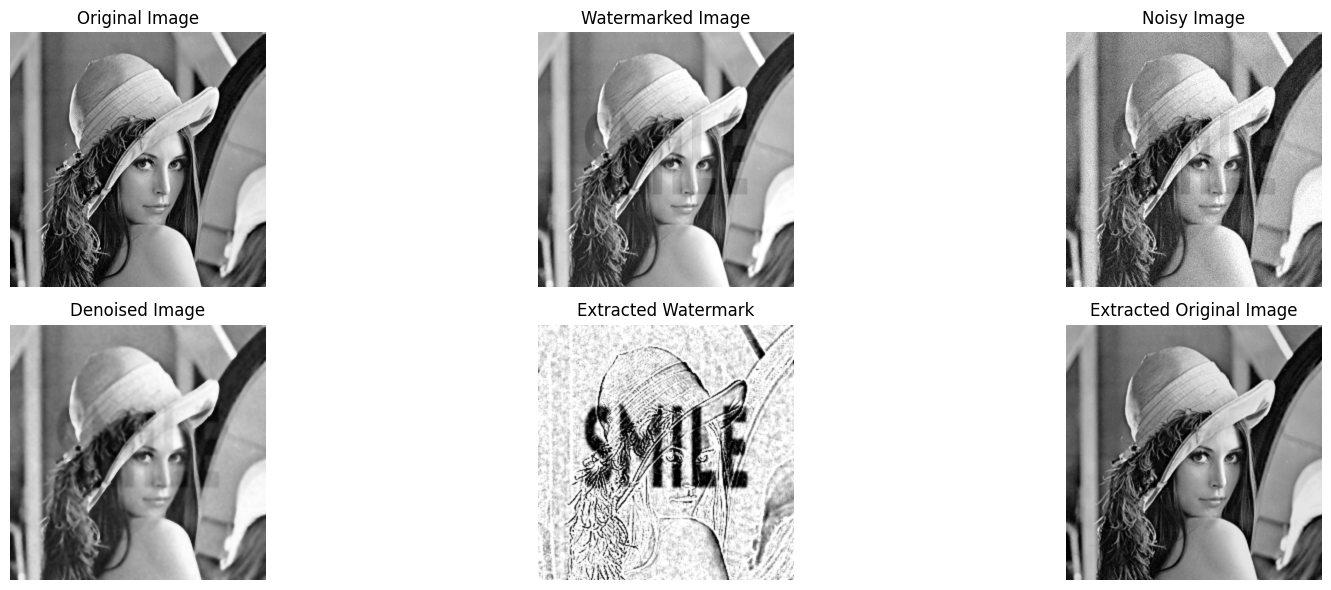

========= IMAGE QUALITY REPORT =========

[Original Image]
  MSE:  0.00
  PSNR: inf dB
  SSIM : 1.0000 
  SNR : inf dB

[Watermarked vs Original]
  MSE:  108.52
  PSNR: 27.78 dB
  SSIM : 0.8535 
  SNR : 14.78 dB

[Noisy vs Original]
  MSE:  103.28
  PSNR: 27.99 dB
  SSIM: 0.4490 
  SNR : 13.58 dB

[Noisy vs Watermarked]
  MSE:  77.11
  PSNR: 29.26 dB
  SSIM : 0.4980 
  SNR : 20.19 dB

[Denoised vs Original]
  MSE:  109.08
  PSNR: 27.75 dB
  SSIM : 0.7256 
  SNR : 14.42 dB

[Denoised vs Watermarked]
  MSE:  34.85
  PSNR: 32.71 dB
  SSIM : 0.8645 
  SNR : 25.13 dB

[Extracted Original vs Original]
  MSE:  24.93
  PSNR: 34.16 dB
  SSIM : 0.9040 
  SNR : 26.15 dB

[Extracted Original vs Watermarked]
  MSE:  147.90
  PSNR: 26.43 dB
  SSIM : 0.9338 
  SNR : 15.90 dB

[Extracted Watermark vs Original Watermark]
  MSE:  63.36
  PSNR: 30.11 dB
  SSIM : 0.1473 
  SNR : 11.15 dB



In [9]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# =========================
# Metrics Calculation Functions
# =========================

def mse(img1, img2):
    """
    Calculates the Mean Squared Error (MSE) between two images.

    Args:
        img1 (numpy.ndarray): The first image.
        img2 (numpy.ndarray): The second image.  Must have the same dimensions as img1.

    Returns:
        float: The MSE value.
    """
    img1_resized = cv2.resize(img1, (img2.shape[1], img2.shape[0])) # Resize img1 to match img2 dimensions
    return np.mean((img1_resized - img2) ** 2) # Calculate the mean of the squared difference

def psnr(img1, img2):
    """
    Calculates the Peak Signal-to-Noise Ratio (PSNR) between two images.

    Args:
        img1 (numpy.ndarray): The first image.
        img2 (numpy.ndarray): The second image.  Must have the same dimensions as img1.

    Returns:
        float: The PSNR value in dB. Returns infinity if MSE is zero.
    """
    img1_resized = cv2.resize(img1, (img2.shape[1], img2.shape[0])) # Resize img1 to match img2 dimensions
    mse_val = mse(img1_resized, img2) # Calculate MSE
    if mse_val == 0:
        return float('inf')  # Return infinity if MSE is 0 (perfect match)
    return 20 * np.log10(255.0 / np.sqrt(mse_val)) # PSNR calculation using 255 as max pixel value

def get_snr(ref, test):
    """
    Calculates the Signal-to-Noise Ratio (SNR) between two images.

    Args:
        ref (numpy.ndarray): The reference image (original).
        test (numpy.ndarray): The test image (noisy or processed). Must have same dims as ref.

    Returns:
        float: The SNR value in dB. Returns infinity if noise power is zero.
    """
    ref = cv2.resize(ref, (test.shape[1], test.shape[0])) # Resize ref to match test image dimensions
    signal_power = np.sum(ref.astype(np.float64) ** 2) # Calculate signal power
    noise_power = np.sum((ref.astype(np.float64) - test.astype(np.float64)) ** 2) # Calculate noise power
    if noise_power == 0:
        return float('inf') # Return infinity if noise power is 0
    return 10 * np.log10(signal_power / noise_power) # SNR calculation

def get_ssim(img1, img2):
    """
    Calculates the Structural Similarity Index (SSIM) between two images.

    Args:
        img1 (numpy.ndarray): The first image.
        img2 (numpy.ndarray): The second image.  Must have the same dimensions.

    Returns:
        float: The SSIM value (between -1 and 1, higher is better).
    """
    img1_resized = cv2.resize(img1, (img2.shape[1], img2.shape[0])) # Resize img1 to match img2 dimensions
    ssim_val = ssim(img1_resized, img2, data_range=255) # Calculate SSIM with pixel range 0-255
    return ssim_val

def get_metrics(img1, img2):
    """
    Calculates and returns a set of image quality metrics.

    Args:
        img1 (numpy.ndarray): The first image.
        img2 (numpy.ndarray): The second image.  Must have the same dimensions.

    Returns:
        tuple: A tuple containing (MSE, PSNR, SSIM, SNR).
    """
    return mse(img1, img2), psnr(img1, img2), get_ssim(img1, img2), get_snr(img1, img2)

def awgn(image, snr_db):
    """
    Adds Additive White Gaussian Noise to an image.

    Args:
        image (numpy.ndarray): The input image.
        snr_db (float): The desired SNR in dB.

    Returns:
        numpy.ndarray: The noisy image.
    """
    in_shape = image.shape # Store original image shape
    image = image.astype(np.float64).reshape(-1) # Flatten the image to 1D array, convert to float64
    signal_power = np.mean(image ** 2) # Calculate signal power
    signal_power_db = 10 * np.log10(signal_power / 1.0)  # Use 1.0 as reference, calculate signal power in dB
    noise_power_db = signal_power_db - snr_db # Calculate noise power in dB
    noise_power = 10 ** (noise_power_db / 10) # Convert noise power from dB to linear scale
    noise = np.random.normal(0, np.sqrt(noise_power), image.shape) # Generate Gaussian noise
    noisy_image = image + noise # Add noise to the image
    noisy_image = np.clip(noisy_image, 0, 255).reshape(in_shape).astype(np.uint8) # Clip pixel values and reshape
    return noisy_image

# =========================
# Load Images
# =========================

original_image_path = '/content/original_image.jpg'  # Replace with the actual path to your original image
watermark_image_path = '/content/watermark_image.jpg' # Replace with the actual path to your watermark image

original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE) # Load original image as grayscale
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE) # Load watermark image as grayscale

if original_image is None or watermark_image is None:
    print("Error loading images. Check the paths.")
    exit()

# Resize watermark to match original image size for addition
watermark = cv2.resize(watermark_image, (original_image.shape[1], original_image.shape[0]))

# =========================
# Watermark Embedding
# =========================

coeffs2 = pywt.dwt2(original_image, 'haar') # Apply 2D Discrete Wavelet Transform (DWT) using 'haar' wavelet
cA, (cH, cV, cD) = coeffs2 # Extract the approximation (cA) and detail coefficients (cH, cV, cD)
alpha = 0.2 # Set the watermark embedding strength

# Resize all bands to the size of cA before embedding.  This is crucial for correct addition.
cA_resized = cv2.resize(cA, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)
cH_resized = cv2.resize(cH, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)
cV_resized = cv2.resize(cV, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)
cD_resized = cv2.resize(cD, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)

cA_watermarked = cA_resized + alpha * watermark # Embed the watermark into the cA coefficients
watermarked_coeffs = (cA_watermarked, (cH_resized, cV_resized, cD_resized)) # Create a tuple of modified coefficients
watermarked_image = pywt.idwt2(watermarked_coeffs, 'haar') # Perform inverse DWT to get watermarked image using 'haar'
watermarked_image = cv2.resize(watermarked_image, original_image.shape[::-1]) # Resize to original image dimensions
watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8) # Clip and convert to uint8

# =========================
# Add Noise and Denoise
# =========================
snr_db = 20  # Adjust the SNR as needed
noisy_image = awgn(watermarked_image, snr_db) # Add AWGN to the watermarked image
denoised_image = cv2.bilateralFilter(noisy_image, 9, 75, 75) # Apply bilateral filter for denoising

# =========================
# Watermark Extraction
# =========================

coeffs_denoised = pywt.dwt2(denoised_image, 'haar') # Apply DWT to the denoised image using 'haar'
cA_denoised, _ = coeffs_denoised # Extract cA coefficients

# Resize cA of original image to the size of cA of denoised image
coeffs_original = pywt.dwt2(original_image, 'haar') # Get original image coefficients using 'haar'
cA_original, _ = coeffs_original
cA_original_resized = cv2.resize(cA_original, cA_denoised.shape[::-1], interpolation=cv2.INTER_CUBIC)


extracted_watermark = (cA_denoised - cA_original_resized) / alpha # Extract the watermark
extracted_watermark = np.clip(extracted_watermark, 0, 255).astype(np.uint8) # Clip and convert
extracted_watermark_resized = cv2.resize(extracted_watermark, (original_image.shape[1], original_image.shape[0])) # Resize

# =========================
# Extract Original Image
# =========================
coeffs_watermarked = pywt.dwt2(watermarked_image, 'haar') # DWT of watermarked image using 'haar'
cA_watermarked_extracted, _ = coeffs_watermarked
extracted_original_coeffs = (cA_watermarked_extracted - alpha * cv2.resize(watermark, cA_watermarked_extracted.shape[::-1], interpolation=cv2.INTER_CUBIC), (coeffs_watermarked[1]))
extracted_original_image = pywt.idwt2(extracted_original_coeffs, 'haar') # Inverse DWT using 'haar'
extracted_original_image = cv2.resize(extracted_original_image, original_image.shape[::-1]) # Resize
extracted_original_image = np.clip(extracted_original_image, 0, 255).astype(np.uint8)

# =========================
# Display Images
# =========================

plt.figure(figsize=(18, 6)) # Create figure for subplots
titles = [
    "Original Image", "Watermarked Image", "Noisy Image",
    "Denoised Image", "Extracted Watermark", "Extracted Original Image"
]
images = [
    original_image, watermarked_image, noisy_image,
    denoised_image, extracted_watermark_resized, extracted_original_image
]

for i in range(6):
    plt.subplot(2, 3, i + 1) # Create subplot
    plt.imshow(images[i], cmap='gray') # Display image in grayscale
    plt.title(titles[i]) # Set subplot title
    plt.axis('off') # Turn off axis labels

plt.tight_layout() # Adjust subplot layout
plt.show() # Show the plot

# =========================
# Image Quality Report
# =========================

print("========= IMAGE QUALITY REPORT =========\n")

# Original vs Itself
mse_val, psnr_val, ssim_val, snr_val = get_metrics(original_image, original_image)
print("[Original Image]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")


# Watermarked vs Original
mse_val, psnr_val, ssim_val, snr_val = get_metrics(original_image, watermarked_image)
print("[Watermarked vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Noisy vs Original
mse_val, psnr_val, ssim_val, snr_val = get_metrics(original_image, noisy_image)
print("[Noisy vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM: {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Noisy vs Watermarked
mse_val, psnr_val, ssim_val, snr_val = get_metrics(watermarked_image, noisy_image)
print("[Noisy vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Denoised vs Original
mse_val, psnr_val, ssim_val, snr_val = get_metrics(original_image, denoised_image)
print("[Denoised vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Denoised vs Watermarked
mse_val, psnr_val, ssim_val, snr_val = get_metrics(watermarked_image, denoised_image)
print("[Denoised vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Original vs Original
mse_val, psnr_val, ssim_val, snr_val = get_metrics(original_image, extracted_original_image)
print("[Extracted Original vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Original vs Watermarked
mse_val, psnr_val, ssim_val, snr_val = get_metrics(watermarked_image, extracted_original_image)
print("[Extracted Original vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Watermark vs Original Watermark
watermark_resized_full = cv2.resize(watermark, extracted_watermark.shape[::-1])
mse_val, psnr_val, ssim_val, snr_val = get_metrics(watermark_resized_full, extracted_watermark)
print("[Extracted Watermark vs Original Watermark]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")


DB4 using AWGN noise

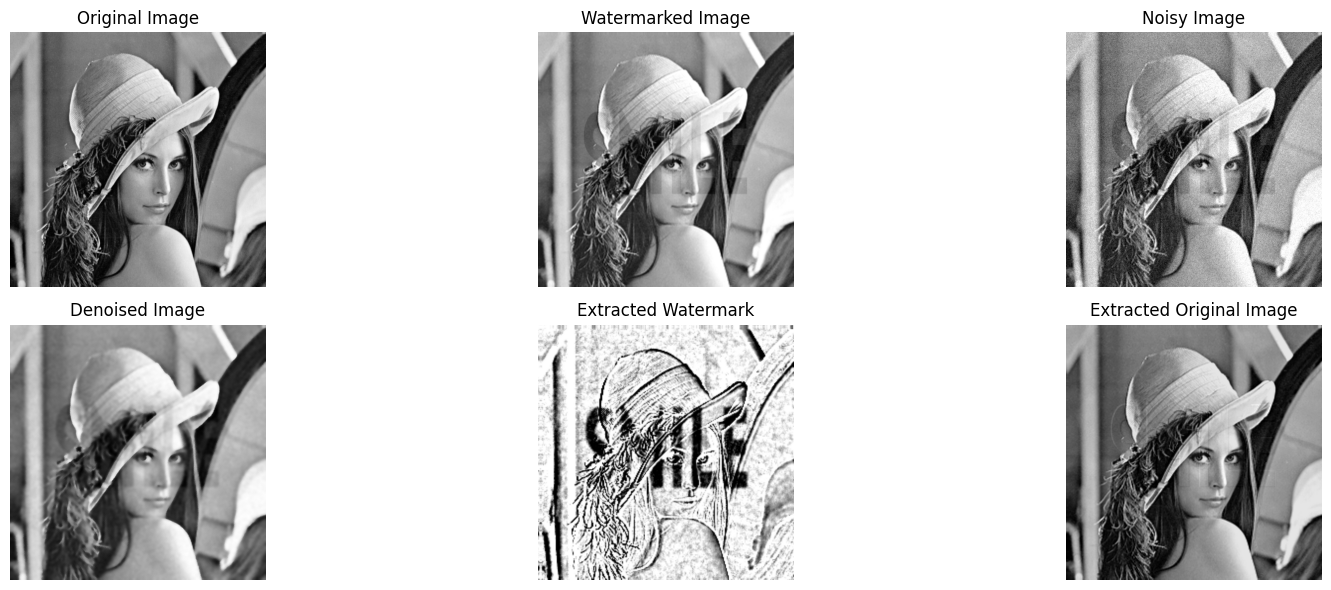

========= IMAGE QUALITY REPORT =========

[Original Image]
  MSE:  0.00
  PSNR: inf dB
  SSIM : 1.0000 
  SNR : inf dB

[Watermarked vs Original]
  MSE:  107.87
  PSNR: 27.80 dB
  SSIM : 0.6474 
  SNR : 12.71 dB

[Noisy vs Original]
  MSE:  103.14
  PSNR: 28.00 dB
  SSIM: 0.3187 
  SNR : 11.91 dB

[Noisy vs Watermarked]
  MSE:  77.39
  PSNR: 29.24 dB
  SSIM : 0.5068 
  SNR : 20.16 dB

[Denoised vs Original]
  MSE:  107.58
  PSNR: 27.81 dB
  SSIM : 0.6517 
  SNR : 13.25 dB

[Denoised vs Watermarked]
  MSE:  37.11
  PSNR: 32.44 dB
  SSIM : 0.8465 
  SNR : 24.48 dB

[Extracted Original vs Original]
  MSE:  51.21
  PSNR: 31.04 dB
  SSIM : 0.6762 
  SNR : 16.27 dB

[Extracted Original vs Watermarked]
  MSE:  146.51
  PSNR: 26.47 dB
  SSIM : 0.9334 
  SNR : 15.91 dB

[Extracted Watermark vs Original Watermark]
  MSE:  59.62
  PSNR: 30.38 dB
  SSIM : 0.1250 
  SNR : 8.80 dB



In [10]:

import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# =========================
# Metrics Calculation Functions
# =========================

def mse(img1, img2):
    img1_resized = cv2.resize(img1, (img2.shape[1], img2.shape[0]))
    return np.mean((img1_resized - img2) ** 2)

def psnr(img1, img2):
    img1_resized = cv2.resize(img1, (img2.shape[1], img2.shape[0]))
    mse_val = mse(img1_resized, img2)
    if mse_val == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse_val))

def get_snr(ref, test):
    ref = cv2.resize(ref, (test.shape[1], test.shape[0]))
    signal_power = np.sum(ref.astype(np.float64) ** 2)
    noise_power = np.sum((ref.astype(np.float64) - test.astype(np.float64)) ** 2)
    if noise_power == 0:
        return float('inf')
    return 10 * np.log10(signal_power / noise_power)

def get_ssim(img1,img2):
    img1_resized = cv2.resize(img1, (img2.shape[1], img2.shape[0]))
    ssim_val=ssim(img1_resized, img2, data_range=255)
    return ssim_val

def get_metrics(img1, img2):
    return mse(img1, img2), psnr(img1, img2), get_ssim(img1, img2), get_snr(img1, img2)

def awgn(image, snr_db):
    """
    Adds Additive White Gaussian Noise to an image.

    Args:
        image (numpy.ndarray): The input image.
        snr_db (float): The desired SNR in dB.

    Returns:
        numpy.ndarray: The noisy image.
    """
    in_shape = image.shape
    image = image.astype(np.float64).reshape(-1)
    signal_power = np.mean(image ** 2)
    signal_power_db = 10 * np.log10(signal_power / 1.0)  # Use 1.0 as reference
    noise_power_db = signal_power_db - snr_db
    noise_power = 10 ** (noise_power_db / 10)
    noise = np.random.normal(0, np.sqrt(noise_power), image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 255).reshape(in_shape).astype(np.uint8)
    return noisy_image

# =========================
# Load Images
# =========================

original_image_path = '/content/original_image.jpg'  # Replace with the actual path to your original image
watermark_image_path = '/content/watermark_image.jpg' # Replace with the actual path to your watermark image

original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None or watermark_image is None:
    print("Error loading images. Check the paths.")
    exit()

# Resize watermark to match original image size for addition
watermark = cv2.resize(watermark_image, (original_image.shape[1], original_image.shape[0]))

# =========================
# Watermark Embedding
# =========================

coeffs2 = pywt.dwt2(original_image, 'db4') # Changed from db10 to db4
cA, (cH, cV, cD) = coeffs2
alpha = 0.2

# Resize all bands to the size of cA before embedding
cA_resized = cv2.resize(cA, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)
cH_resized = cv2.resize(cH, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)
cV_resized = cv2.resize(cV, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)
cD_resized = cv2.resize(cD, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)

cA_watermarked = cA_resized + alpha * watermark
watermarked_coeffs = (cA_watermarked, (cH_resized, cV_resized, cD_resized))
#watermarked_image = pywt.idwt2(watermarked_coeffs, 'db10', output_size=original_image.shape)
watermarked_image = pywt.idwt2(watermarked_coeffs, 'db4') # Changed from db10 to db4
watermarked_image = cv2.resize(watermarked_image, original_image.shape[::-1]) # Resize after IDWT
watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)
#watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)

# =========================
# Add Noise and Denoise
# =========================
snr_db = 20  # Adjust the SNR as needed
noisy_image = awgn(watermarked_image, snr_db)
denoised_image = cv2.bilateralFilter(noisy_image, 9, 75, 75)

# =========================
# Watermark Extraction
# =========================

coeffs_denoised = pywt.dwt2(denoised_image, 'db4') # Changed from db10 to db4
cA_denoised, _ = coeffs_denoised

# Resize cA of original image to the size of cA of denoised image
coeffs_original = pywt.dwt2(original_image, 'db4') # Changed from db10 to db4
cA_original, _ = coeffs_original
cA_original_resized = cv2.resize(cA_original, cA_denoised.shape[::-1], interpolation=cv2.INTER_CUBIC)


extracted_watermark = (cA_denoised - cA_original_resized) / alpha
extracted_watermark = np.clip(extracted_watermark, 0, 255).astype(np.uint8)
extracted_watermark_resized = cv2.resize(extracted_watermark, (original_image.shape[1], original_image.shape[0]))

# =========================
# Extract Original Image
# =========================
coeffs_watermarked = pywt.dwt2(watermarked_image, 'db4') # Changed from db10 to db4
cA_watermarked_extracted, _ = coeffs_watermarked
extracted_original_coeffs = (cA_watermarked_extracted - alpha * cv2.resize(watermark, cA_watermarked_extracted.shape[::-1], interpolation=cv2.INTER_CUBIC), (coeffs_watermarked[1]))
#extracted_original_image = pywt.idwt2(extracted_original_coeffs, 'db10', output_size=original_image.shape)
extracted_original_image = pywt.idwt2(extracted_original_coeffs, 'db4') # Changed from db10 to db4
extracted_original_image = cv2.resize(extracted_original_image, original_image.shape[::-1]) # Resize after IDWT
extracted_original_image = np.clip(extracted_original_image, 0, 255).astype(np.uint8)

# =========================
# Display Images
# =========================

plt.figure(figsize=(18, 6))
titles = [
    "Original Image", "Watermarked Image", "Noisy Image",
    "Denoised Image", "Extracted Watermark", "Extracted Original Image"
]
images = [
    original_image, watermarked_image, noisy_image,
    denoised_image, extracted_watermark_resized, extracted_original_image
]

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# Image Quality Report
# =========================

print("========= IMAGE QUALITY REPORT =========\n")

# Original vs Itself
mse_val, psnr_val,ssim_val, snr_val = get_metrics(original_image, original_image)
print("[Original Image]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")


# Watermarked vs Original
mse_val, psnr_val,ssim_val, snr_val  = get_metrics(original_image, watermarked_image)
print("[Watermarked vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Noisy vs Original
mse_val, psnr_val,ssim_val, snr_val = get_metrics(original_image, noisy_image)
print("[Noisy vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM: {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Noisy vs Watermarked
mse_val, psnr_val,ssim_val, snr_val = get_metrics(watermarked_image, noisy_image)
print("[Noisy vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Denoised vs Original
mse_val, psnr_val, ssim_val,snr_val  = get_metrics(original_image, denoised_image)
print("[Denoised vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Denoised vs Watermarked
mse_val, psnr_val,ssim_val, snr_val = get_metrics(watermarked_image, denoised_image)
print("[Denoised vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Original vs Original
mse_val, psnr_val,ssim_val, snr_val = get_metrics(original_image, extracted_original_image)
print("[Extracted Original vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Original vs Watermarked
mse_val, psnr_val,ssim_val, snr_val = get_metrics(watermarked_image, extracted_original_image)
print("[Extracted Original vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Watermark vs Original Watermark
watermark_resized_full = cv2.resize(watermark, extracted_watermark.shape[::-1])
mse_val, psnr_val,ssim_val, snr_val = get_metrics(watermark_resized_full, extracted_watermark)
print("[Extracted Watermark vs Original Watermark]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")


DB10 using AWGN

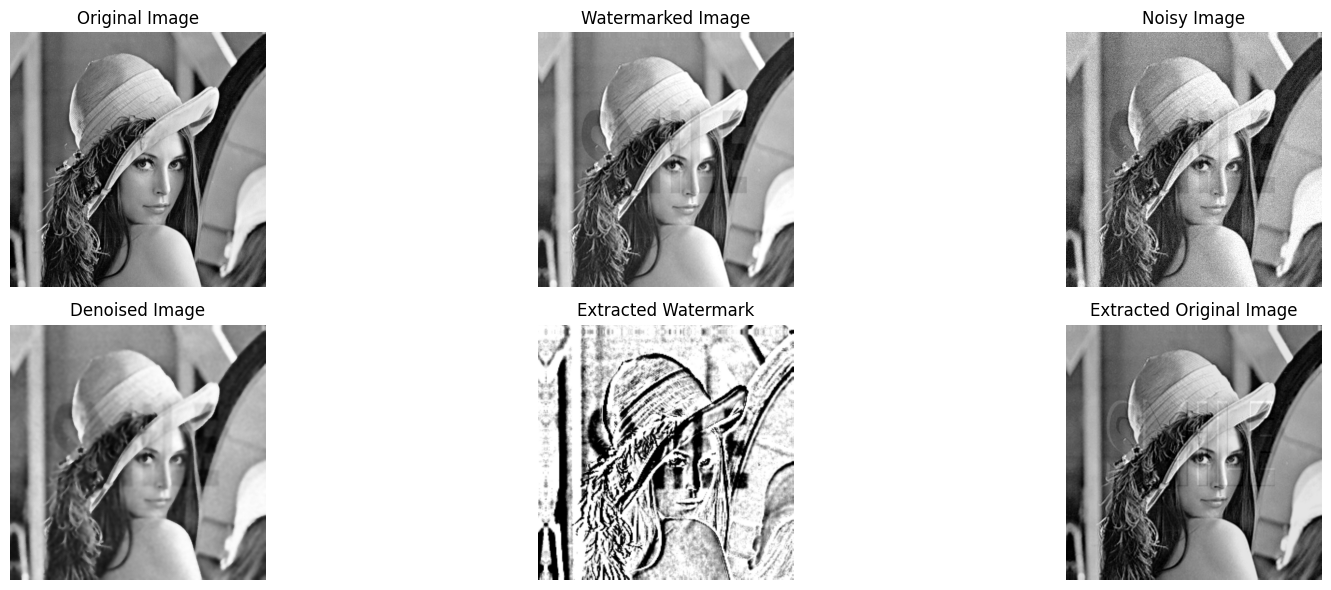

========= IMAGE QUALITY REPORT =========

[Original Image]
  MSE:  0.00
  PSNR: inf dB
  SSIM : 1.0000 
  SNR : inf dB

[Watermarked vs Original]
  MSE:  107.99
  PSNR: 27.80 dB
  SSIM : 0.4498 
  SNR : 9.83 dB

[Noisy vs Original]
  MSE:  103.22
  PSNR: 27.99 dB
  SSIM: 0.1889 
  SNR : 9.42 dB

[Noisy vs Watermarked]
  MSE:  77.17
  PSNR: 29.26 dB
  SSIM : 0.5072 
  SNR : 20.16 dB

[Denoised vs Original]
  MSE:  107.69
  PSNR: 27.81 dB
  SSIM : 0.4814 
  SNR : 10.48 dB

[Denoised vs Watermarked]
  MSE:  37.17
  PSNR: 32.43 dB
  SSIM : 0.8434 
  SNR : 24.44 dB

[Extracted Original vs Original]
  MSE:  67.31
  PSNR: 29.85 dB
  SSIM : 0.4586 
  SNR : 11.24 dB

[Extracted Original vs Watermarked]
  MSE:  145.11
  PSNR: 26.51 dB
  SSIM : 0.9326 
  SNR : 15.92 dB

[Extracted Watermark vs Original Watermark]
  MSE:  52.07
  PSNR: 30.96 dB
  SSIM : 0.1018 
  SNR : 6.86 dB



In [12]:
import cv2
import pywt
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim

# =========================
# Metrics Calculation Functions
# =========================

def mse(img1, img2):
    img1_resized = cv2.resize(img1, (img2.shape[1], img2.shape[0]))
    return np.mean((img1_resized - img2) ** 2)

def psnr(img1, img2):
    img1_resized = cv2.resize(img1, (img2.shape[1], img2.shape[0]))
    mse_val = mse(img1_resized, img2)
    if mse_val == 0:
        return float('inf')
    return 20 * np.log10(255.0 / np.sqrt(mse_val))

def get_snr(ref, test):
    ref = cv2.resize(ref, (test.shape[1], test.shape[0]))
    signal_power = np.sum(ref.astype(np.float64) ** 2)
    noise_power = np.sum((ref.astype(np.float64) - test.astype(np.float64)) ** 2)
    if noise_power == 0:
        return float('inf')
    return 10 * np.log10(signal_power / noise_power)

def get_ssim(img1,img2):
    img1_resized = cv2.resize(img1, (img2.shape[1], img2.shape[0]))
    ssim_val=ssim(img1_resized, img2, data_range=255)
    return ssim_val

def get_metrics(img1, img2):
    return mse(img1, img2), psnr(img1, img2), get_ssim(img1, img2), get_snr(img1, img2)

def awgn(image, snr_db):
    """
    Adds Additive White Gaussian Noise to an image.

    Args:
        image (numpy.ndarray): The input image.
        snr_db (float): The desired SNR in dB.

    Returns:
        numpy.ndarray: The noisy image.
    """
    in_shape = image.shape
    image = image.astype(np.float64).reshape(-1)
    signal_power = np.mean(image ** 2)
    signal_power_db = 10 * np.log10(signal_power / 1.0)  # Use 1.0 as reference
    noise_power_db = signal_power_db - snr_db
    noise_power = 10 ** (noise_power_db / 10)
    noise = np.random.normal(0, np.sqrt(noise_power), image.shape)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 255).reshape(in_shape).astype(np.uint8)
    return noisy_image

# =========================
# Load Images
# =========================

original_image_path = '/content/original_image.jpg'  # Replace with the actual path to your original image
watermark_image_path = '/content/watermark_image.jpg' # Replace with the actual path to your watermark image

original_image = cv2.imread(original_image_path, cv2.IMREAD_GRAYSCALE)
watermark_image = cv2.imread(watermark_image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None or watermark_image is None:
    print("Error loading images. Check the paths.")
    exit()

# Resize watermark to match original image size for addition
watermark = cv2.resize(watermark_image, (original_image.shape[1], original_image.shape[0]))

# =========================
# Watermark Embedding
# =========================

coeffs2 = pywt.dwt2(original_image, 'db10')
cA, (cH, cV, cD) = coeffs2
alpha = 0.2

# Resize all bands to the size of cA before embedding
cA_resized = cv2.resize(cA, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)
cH_resized = cv2.resize(cH, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)
cV_resized = cv2.resize(cV, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)
cD_resized = cv2.resize(cD, watermark.shape[::-1], interpolation=cv2.INTER_CUBIC)

cA_watermarked = cA_resized + alpha * watermark
watermarked_coeffs = (cA_watermarked, (cH_resized, cV_resized, cD_resized))
#watermarked_image = pywt.idwt2(watermarked_coeffs, 'db10', output_size=original_image.shape)
watermarked_image = pywt.idwt2(watermarked_coeffs, 'db10') # Remove output_size
watermarked_image = cv2.resize(watermarked_image, original_image.shape[::-1]) # Resize after IDWT
watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)
#watermarked_image = np.clip(watermarked_image, 0, 255).astype(np.uint8)

# =========================
# Add Noise and Denoise
# =========================
snr_db = 20  # Adjust the SNR as needed
noisy_image = awgn(watermarked_image, snr_db)
denoised_image = cv2.bilateralFilter(noisy_image, 9, 75, 75)

# =========================
# Watermark Extraction
# =========================

coeffs_denoised = pywt.dwt2(denoised_image, 'db10')
cA_denoised, _ = coeffs_denoised

# Resize cA of original image to the size of cA of denoised image
coeffs_original = pywt.dwt2(original_image, 'db10')
cA_original, _ = coeffs_original
cA_original_resized = cv2.resize(cA_original, cA_denoised.shape[::-1], interpolation=cv2.INTER_CUBIC)


extracted_watermark = (cA_denoised - cA_original_resized) / alpha
extracted_watermark = np.clip(extracted_watermark, 0, 255).astype(np.uint8)
extracted_watermark_resized = cv2.resize(extracted_watermark, (original_image.shape[1], original_image.shape[0]))

# =========================
# Extract Original Image
# =========================
coeffs_watermarked = pywt.dwt2(watermarked_image, 'db10')
cA_watermarked_extracted, _ = coeffs_watermarked
extracted_original_coeffs = (cA_watermarked_extracted - alpha * cv2.resize(watermark, cA_watermarked_extracted.shape[::-1], interpolation=cv2.INTER_CUBIC), (coeffs_watermarked[1]))
#extracted_original_image = pywt.idwt2(extracted_original_coeffs, 'db10', output_size=original_image.shape)
extracted_original_image = pywt.idwt2(extracted_original_coeffs, 'db10')
extracted_original_image = cv2.resize(extracted_original_image, original_image.shape[::-1]) # Resize after IDWT
extracted_original_image = np.clip(extracted_original_image, 0, 255).astype(np.uint8)

# =========================
# Display Images
# =========================

plt.figure(figsize=(18, 6))
titles = [
    "Original Image", "Watermarked Image", "Noisy Image",
    "Denoised Image", "Extracted Watermark", "Extracted Original Image"
]
images = [
    original_image, watermarked_image, noisy_image,
    denoised_image, extracted_watermark_resized, extracted_original_image
]

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

# =========================
# Image Quality Report
# =========================

print("========= IMAGE QUALITY REPORT =========\n")

# Original vs Itself
mse_val, psnr_val,ssim_val, snr_val = get_metrics(original_image, original_image)
print("[Original Image]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")


# Watermarked vs Original
mse_val, psnr_val,ssim_val, snr_val  = get_metrics(original_image, watermarked_image)
print("[Watermarked vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Noisy vs Original
mse_val, psnr_val,ssim_val, snr_val = get_metrics(original_image, noisy_image)
print("[Noisy vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM: {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Noisy vs Watermarked
mse_val, psnr_val,ssim_val, snr_val = get_metrics(watermarked_image, noisy_image)
print("[Noisy vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Denoised vs Original
mse_val, psnr_val, ssim_val,snr_val  = get_metrics(original_image, denoised_image)
print("[Denoised vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Denoised vs Watermarked
mse_val, psnr_val,ssim_val, snr_val = get_metrics(watermarked_image, denoised_image)
print("[Denoised vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Original vs Original
mse_val, psnr_val,ssim_val, snr_val = get_metrics(original_image, extracted_original_image)
print("[Extracted Original vs Original]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Original vs Watermarked
mse_val, psnr_val,ssim_val, snr_val = get_metrics(watermarked_image, extracted_original_image)
print("[Extracted Original vs Watermarked]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")

# Extracted Watermark vs Original Watermark
watermark_resized_full = cv2.resize(watermark, extracted_watermark.shape[::-1])
mse_val, psnr_val,ssim_val, snr_val = get_metrics(watermark_resized_full, extracted_watermark)
print("[Extracted Watermark vs Original Watermark]")
print(f"  MSE:  {mse_val:.2f}")
print(f"  PSNR: {psnr_val:.2f} dB")
print(f"  SSIM : {ssim_val:.4f} ")
print(f"  SNR : {snr_val:.2f} dB\n")
